In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
obs_path = "../data/processed/ethiopia_fi_unified_data_enriched.csv"
impact_path = "../data/processed/impact_links_enriched.csv"

observations = pd.read_csv(obs_path)
impact_links = pd.read_csv(impact_path)

observations.head()


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [3]:
observations.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            43 non-null     object 
 1   record_type          45 non-null     object 
 2   category             11 non-null     object 
 3   pillar               34 non-null     object 
 4   indicator            44 non-null     object 
 5   indicator_code       44 non-null     object 
 6   indicator_direction  33 non-null     object 
 7   value_numeric        34 non-null     float64
 8   value_text           10 non-null     object 
 9   value_type           43 non-null     object 
 10  unit                 33 non-null     object 
 11  observation_date     45 non-null     object 
 12  period_start         10 non-null     object 
 13  period_end           10 non-null     object 
 14  fiscal_year          43 non-null     object 
 15  gender               43 non-null     objec

In [4]:
observations.isna().sum().sort_values(ascending=False).head(10)


impact_estimate      45
region               45
related_indicator    45
relationship_type    45
evidence_basis       45
lag_months           45
impact_direction     45
impact_magnitude     45
notes                43
value_text           35
dtype: int64

In [5]:
observations['record_type'].value_counts()


record_type
observation    31
event          11
target          3
Name: count, dtype: int64

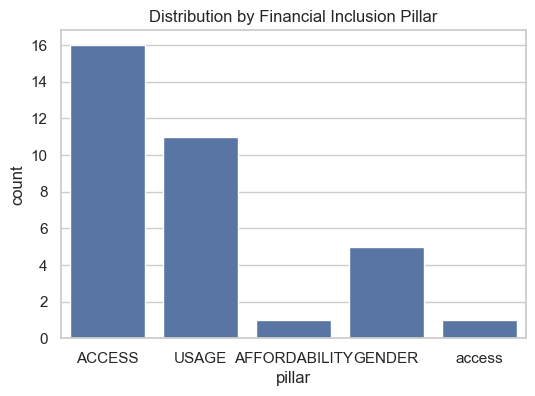

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=observations, x='pillar')
plt.title("Distribution by Financial Inclusion Pillar")
plt.show()


In [7]:
observations['observation_date'] = pd.to_datetime(
    observations['observation_date'], errors='coerce'
)

observations['year'] = observations['observation_date'].dt.year


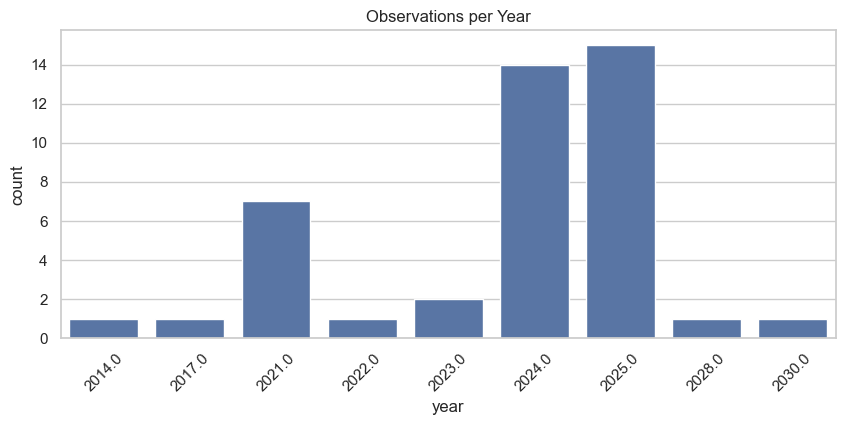

In [8]:
plt.figure(figsize=(10,4))
sns.countplot(x='year', data=observations)
plt.title("Observations per Year")
plt.xticks(rotation=45)
plt.show()


In [9]:
observations['indicator_code'].value_counts()


indicator_code
ACC_OWNERSHIP         7
ACC_FAYDA             4
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_MM_SHARE          2
GEN_GAP_ACC           2
USG_ATM_COUNT         1
USG_P2P_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_ATM_VALUE         1
ACC_MOBILE_PEN        1
USG_MPESA_ACTIVE      1
USG_MPESA_USERS       1
AFF_DATA_INCOME       1
USG_ACTIVE_RATE       1
GEN_GAP_MOBILE        1
EVT_TELEBIRR          1
EVT_SAFARICOM         1
EVT_MPESA             1
EVT_FAYDA             1
EVT_FX_REFORM         1
EVT_CROSSOVER         1
EVT_MPESA_INTEROP     1
EVT_ETHIOPAY          1
EVT_NFIS2             1
EVT_SAFCOM_PRICE      1
ACC_OWN_FEMALE        1
Name: count, dtype: int64

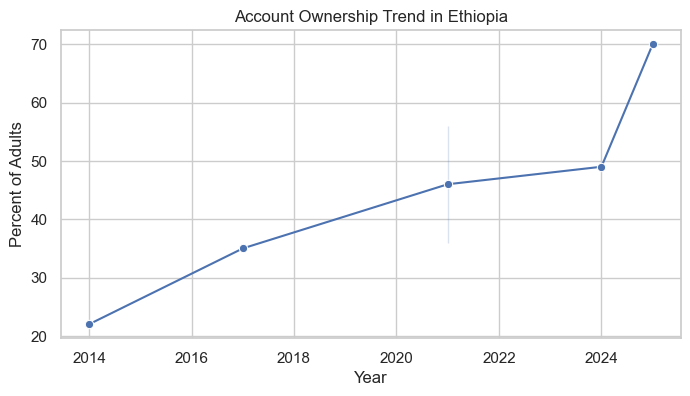

In [10]:
acc = observations[
    observations['indicator_code'] == 'ACC_OWNERSHIP'
]

plt.figure(figsize=(8,4))
sns.lineplot(data=acc, x='year', y='value_numeric', marker='o')
plt.title("Account Ownership Trend in Ethiopia")
plt.ylabel("Percent of Adults")
plt.xlabel("Year")
plt.show()


In [11]:
acc_sorted = acc.sort_values("year")
acc_sorted['growth_pp'] = acc_sorted['value_numeric'].diff()

acc_sorted[['year', 'value_numeric', 'growth_pp']]


,year,value_numeric,growth_pp
0,2014.0,22.0,NaN
1,2017.0,35.0,13.0
2,2021.0,46.0,11.0
3,2021.0,56.0,10.0
4,2021.0,36.0,-20.0
5,2024.0,49.0,13.0
30,2025.0,70.0,21.0


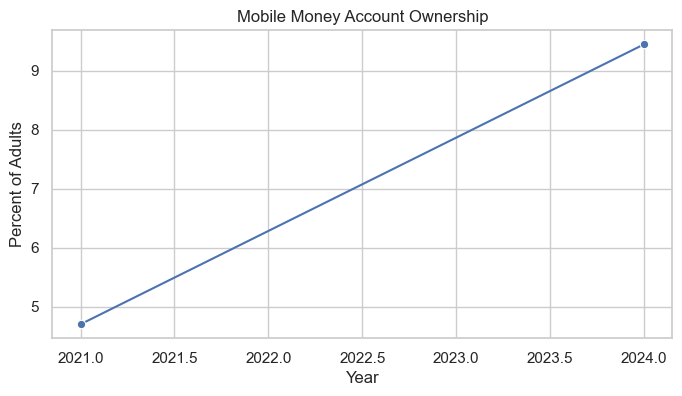

In [12]:
mm = observations[
    observations['indicator_code'] == 'ACC_MM_ACCOUNT'
]

plt.figure(figsize=(8,4))
sns.lineplot(data=mm, x='year', y='value_numeric', marker='o')
plt.title("Mobile Money Account Ownership")
plt.ylabel("Percent of Adults")
plt.xlabel("Year")
plt.show()


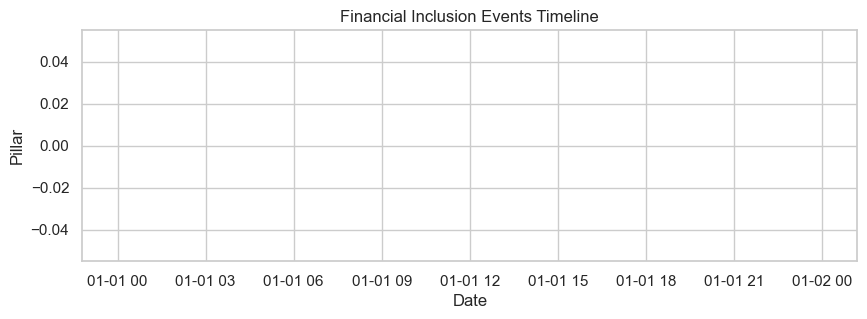

In [13]:
events = observations[observations['record_type'] == 'event']

plt.figure(figsize=(10,3))
plt.scatter(
    events['observation_date'],
    events['pillar'],
    alpha=0.6
)
plt.title("Financial Inclusion Events Timeline")
plt.xlabel("Date")
plt.ylabel("Pillar")
plt.show()


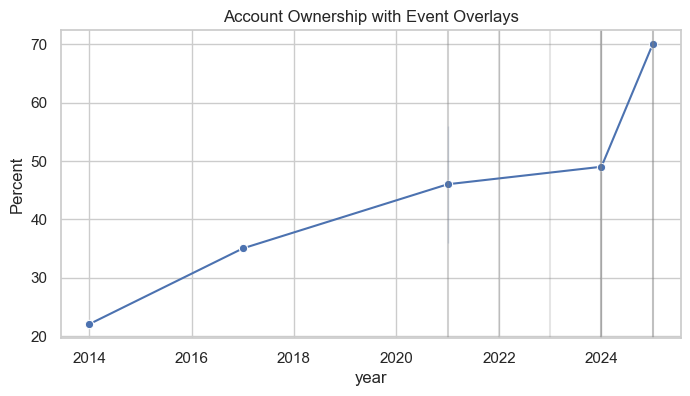

In [14]:
plt.figure(figsize=(8,4))
sns.lineplot(data=acc, x='year', y='value_numeric', marker='o')

for _, row in events.iterrows():
    plt.axvline(row['observation_date'].year, color='gray', alpha=0.2)

plt.title("Account Ownership with Event Overlays")
plt.ylabel("Percent")
plt.show()


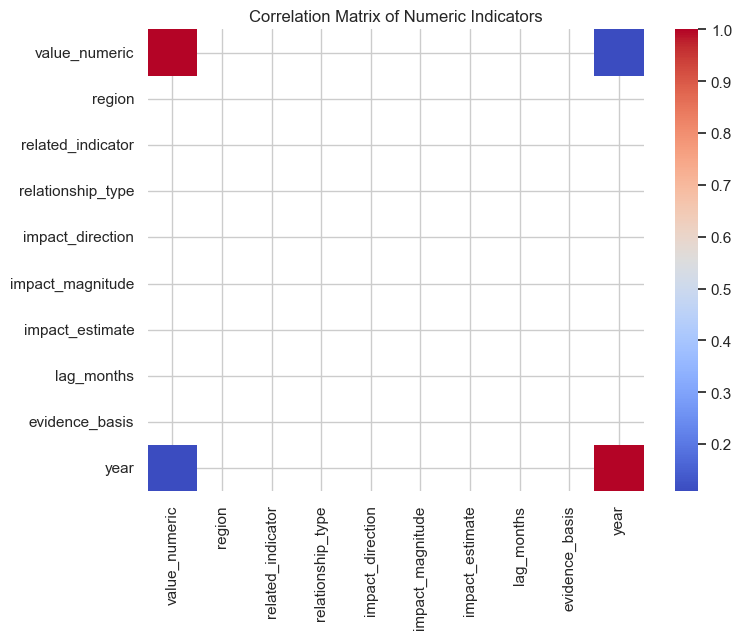

In [15]:
num_cols = observations.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Numeric Indicators")
plt.show()


In [17]:
impact_links.groupby(
    ['pillar', 'related_indicator', 'impact_direction']
).size().reset_index(name='count')


,pillar,related_indicator,impact_direction,count
0,ACCESS,ACC_4G_COV,increase,1
1,ACCESS,ACC_MM_ACCOUNT,increase,1
2,ACCESS,ACC_OWNERSHIP,increase,2
3,AFFORDABILITY,AFF_DATA_INCOME,decrease,1
4,AFFORDABILITY,AFF_DATA_INCOME,increase,2
5,GENDER,GEN_GAP_ACC,decrease,1
6,USAGE,USG_MPESA_ACTIVE,increase,1
7,USAGE,USG_MPESA_USERS,increase,1
8,USAGE,USG_P2P_COUNT,increase,3
9,USAGE,USG_TELEBIRR_USERS,increase,1


## Key Insights (Task 2)

1. Account ownership growth slowed after 2021 despite rapid mobile money expansion.
2. Mobile money accounts increased faster than overall access.
3. Events cluster after regulatory reforms and telecom liberalization.
4. Access indicators are better covered than Usage indicators.
5. Infrastructure and policy events appear to precede usage growth.

### Data Gaps
- Limited post-2022 survey data
- Sparse gender and rural/urban splits
- Few usage intensity indicators

### Hypotheses for Task 3
- Event impacts are lagged, not immediate
- Registration ≠ active usage
- Supply expansion outpaced demand readiness
